In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [90]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist

# Make plots look a bit cleaner
sns.set_theme(style="whitegrid")

# Reproducibility: any randomness we use later will be seeded with this
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist

# Make plots look a bit cleaner
sns.set_theme(style="whitegrid")

# Reproducibility: any randomness we use later will be seeded with this
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [93]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [94]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

print("\nX dtype:", X_train.dtype)
print("y dtype:", y_train.dtype)

print("\nPixel min:", X_train.min())
print("Pixel max:", X_train.max())

print("\nUnique labels:", np.unique(y_train))

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape:  (10000, 28, 28)
y_test shape:  (10000,)

X dtype: uint8
y dtype: uint8

Pixel min: 0
Pixel max: 255

Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [95]:
print("Label of first image:", y_train[0])
print("\nFirst image as numbers (28x28):")
print(X_train[0])

Label of first image: 5

First image as numbers (28x28):
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0  

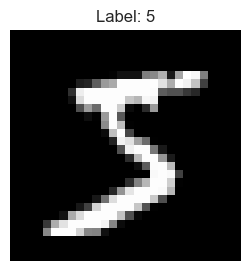

In [96]:
idx = 0
plt.figure(figsize=(3, 3))
plt.imshow(X_train[idx], cmap="gray")
plt.title(f"Label: {y_train[idx]}")
plt.axis("off")
plt.show()

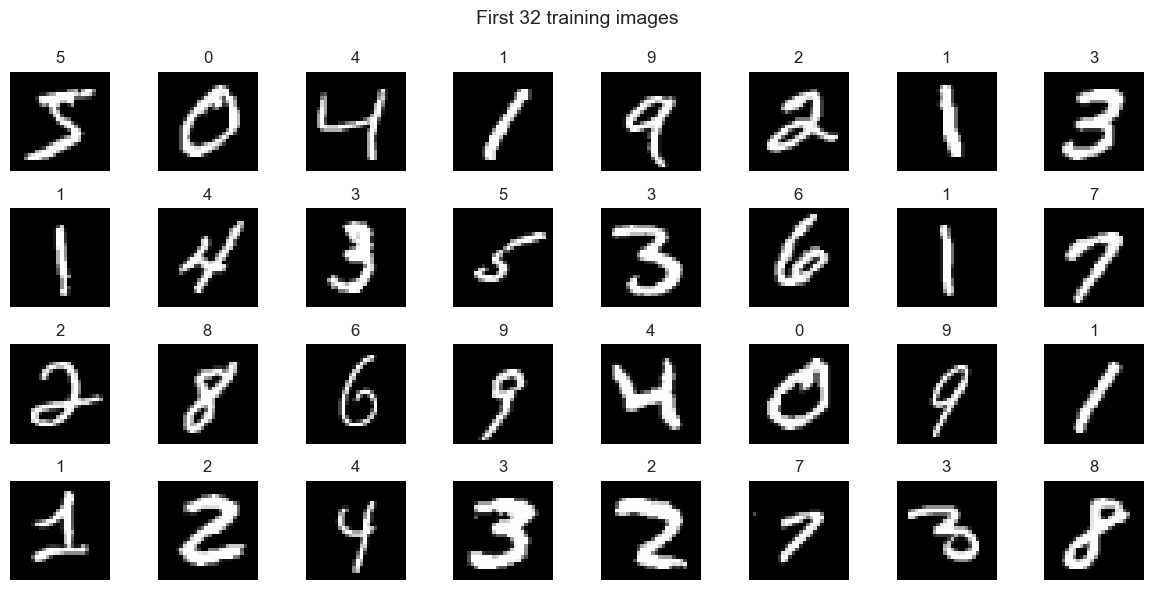

In [97]:
fig, axes = plt.subplots(4, 8, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap="gray")
    ax.set_title(y_train[i])
    ax.axis("off")

plt.suptitle("First 32 training images", fontsize=14)
plt.tight_layout()
plt.show()

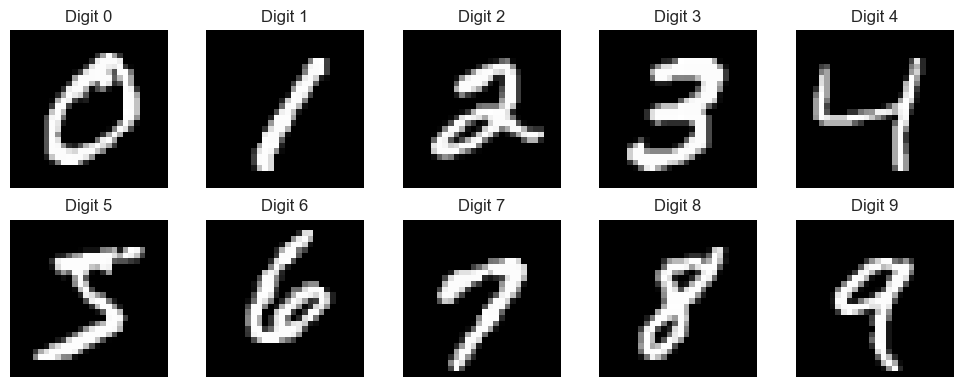

In [98]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for digit, ax in enumerate(axes.flat):
    first_example = X_train[y_train == digit][0]
    ax.imshow(first_example, cmap="gray")
    ax.set_title(f"Digit {digit}")
    ax.axis("off")

plt.tight_layout()
plt.show()

0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


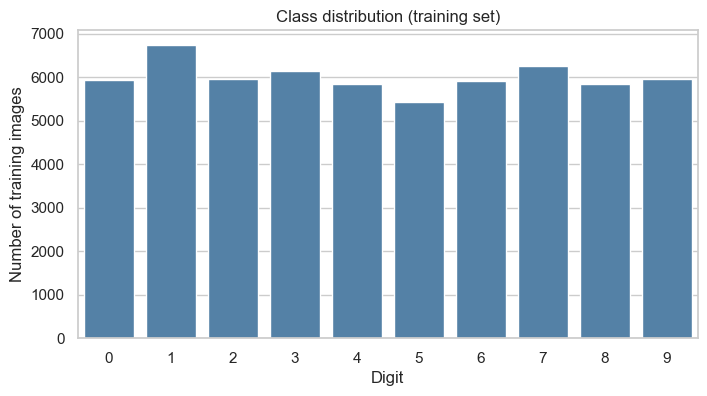

In [99]:
class_counts = pd.Series(y_train).value_counts().sort_index()
print(class_counts)

plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, color="steelblue")
plt.xlabel("Digit")
plt.ylabel("Number of training images")
plt.title("Class distribution (training set)")
plt.show()

In [100]:
print("Missing values in X_train:", np.isnan(X_train.astype(float)).sum())
print("Missing values in y_train:", pd.Series(y_train).isna().sum())

Missing values in X_train: 0
Missing values in y_train: 0


In [101]:
flat = X_train.reshape(len(X_train), -1)       # (60000, 784)
unique_rows = np.unique(flat, axis=0)

print("Total training images:", len(flat))
print("Unique training images:", len(unique_rows))

Total training images: 60000
Unique training images: 60000


In [102]:
print("Mean pixel value:", X_train.mean())
print("Std of pixel values:", X_train.std())

# Share of pixels that are exactly zero (pure background)
print("Fraction of zero pixels:", (X_train == 0).mean())

Mean pixel value: 33.318421449829934
Std of pixel values: 78.56748998339798
Fraction of zero pixels: 0.8087977040816327


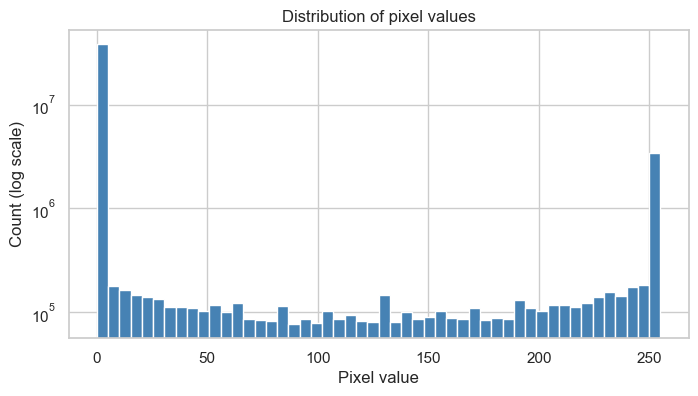

In [103]:
plt.figure(figsize=(8, 4))
plt.hist(X_train.ravel(), bins=50, color="steelblue")
plt.yscale("log")
plt.xlabel("Pixel value")
plt.ylabel("Count (log scale)")
plt.title("Distribution of pixel values")
plt.show()

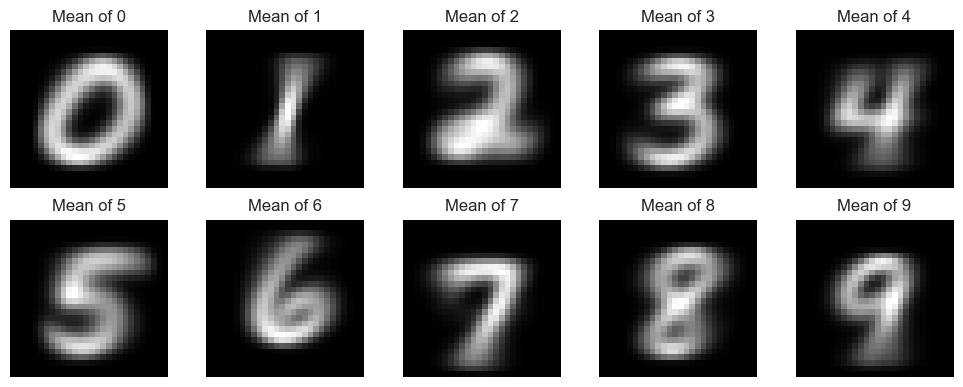

In [104]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for digit, ax in enumerate(axes.flat):
    mean_img = X_train[y_train == digit].mean(axis=0)
    ax.imshow(mean_img, cmap="gray")
    ax.set_title(f"Mean of {digit}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [105]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Before:", X_train.shape, "->", "After:", X_train_flat.shape)
print("Before:", X_test.shape, "->", "After:", X_test_flat.shape)

Before: (60000, 28, 28) -> After: (60000, 784)
Before: (10000, 28, 28) -> After: (10000, 784)


In [106]:
X_train_scaled = X_train_flat.astype("float32") / 255.0
X_test_scaled = X_test_flat.astype("float32") / 255.0

print("Train min/max:", X_train_scaled.min(), X_train_scaled.max())
print("Test min/max: ", X_test_scaled.min(), X_test_scaled.max())
print("dtype:", X_train_scaled.dtype)

Train min/max: 0.0 1.0
Test min/max:  0.0 1.0
dtype: float32


In [107]:
# Final variables used for ALL traditional ML models
X_train_final = X_train_scaled   # shape (60000, 784), floats in [0, 1]
X_test_final = X_test_scaled     # shape (10000, 784)
y_train_final = y_train          # shape (60000,), ints 0-9
y_test_final = y_test            # shape (10000,)

print("X_train:", X_train_final.shape, "| y_train:", y_train_final.shape)
print("X_test: ", X_test_final.shape, "| y_test: ", y_test_final.shape)

X_train: (60000, 784) | y_train: (60000,)
X_test:  (10000, 784) | y_test:  (10000,)


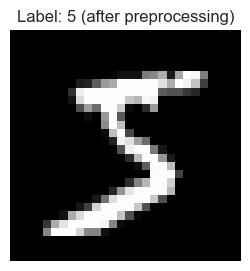

In [108]:
idx = 0
plt.figure(figsize=(3, 3))
plt.imshow(X_train_final[idx].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y_train_final[idx]} (after preprocessing)")
plt.axis("off")
plt.show()

In [109]:
print("Images identical (after rescaling back)?",
      np.allclose(X_train_final[idx].reshape(28, 28) * 255, X_train[idx]))

Images identical (after rescaling back)? True


In [110]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

In [111]:
log_reg = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)

start = time.time()
log_reg.fit(X_train_final, y_train_final)
lr_train_time = time.time() - start

start = time.time()
y_pred_lr = log_reg.predict(X_test_final)
lr_pred_time = time.time() - start

print(f"Training time:   {lr_train_time:.1f} s")
print(f"Prediction time: {lr_pred_time:.2f} s")

Training time:   29.1 s
Prediction time: 0.05 s


In [112]:
acc = accuracy_score(y_test_final, y_pred_lr)
prec = precision_score(y_test_final, y_pred_lr, average="macro")
rec = recall_score(y_test_final, y_pred_lr, average="macro")
f1 = f1_score(y_test_final, y_pred_lr, average="macro")

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.9261
Precision: 0.9251
Recall:    0.9250
F1-score:  0.9250


In [113]:
print(classification_report(y_test_final, y_pred_lr, digits=3))

              precision    recall  f1-score   support

           0      0.952     0.977     0.964       980
           1      0.962     0.979     0.970      1135
           2      0.929     0.901     0.915      1032
           3      0.905     0.912     0.908      1010
           4      0.937     0.938     0.937       982
           5      0.895     0.873     0.884       892
           6      0.941     0.950     0.945       958
           7      0.933     0.923     0.928      1028
           8      0.884     0.879     0.882       974
           9      0.912     0.919     0.916      1009

    accuracy                          0.926     10000
   macro avg      0.925     0.925     0.925     10000
weighted avg      0.926     0.926     0.926     10000



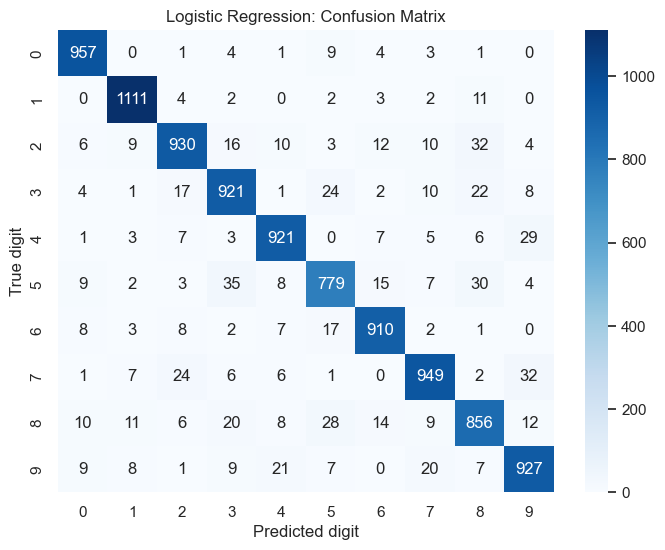

In [114]:
cm = confusion_matrix(y_test_final, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted digit")
plt.ylabel("True digit")
plt.title("Logistic Regression: Confusion Matrix")
plt.show()

Correct: 9261 | Incorrect: 739


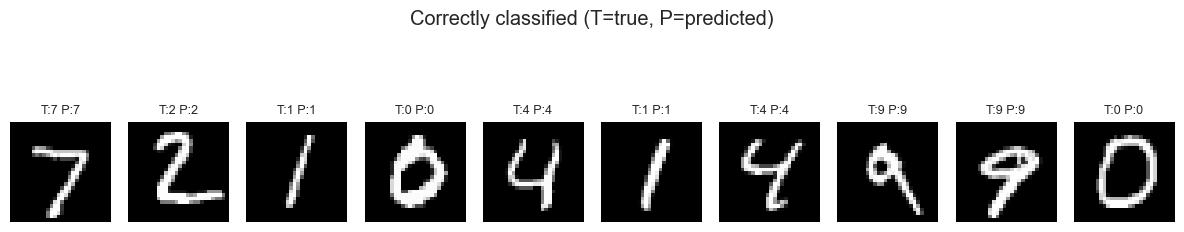

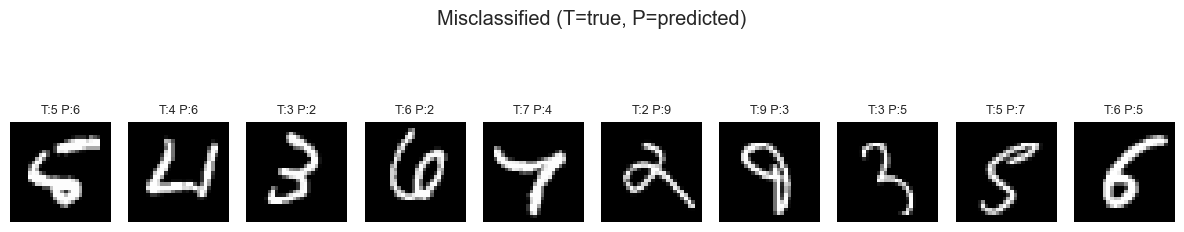

In [115]:
correct_idx = np.where(y_pred_lr == y_test_final)[0]
wrong_idx = np.where(y_pred_lr != y_test_final)[0]

print("Correct:", len(correct_idx), "| Incorrect:", len(wrong_idx))

def show_predictions(indices, title, n=10):
    plt.figure(figsize=(12, 3))
    for i, idx in enumerate(indices[:n]):
        plt.subplot(1, n, i + 1)
        plt.imshow(X_test[idx], cmap="gray")
        plt.title(f"T:{y_test_final[idx]} P:{y_pred_lr[idx]}", fontsize=9)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_predictions(correct_idx, "Correctly classified (T=true, P=predicted)")
show_predictions(wrong_idx, "Misclassified (T=true, P=predicted)")

In [116]:
proba = log_reg.predict_proba(X_test_final)
print("Probability matrix shape:", proba.shape)       # (10000, 10)

# Confidence = probability of the predicted class
confidence = proba.max(axis=1)

print(f"Avg confidence on correct predictions:   {confidence[correct_idx].mean():.3f}")
print(f"Avg confidence on incorrect predictions: {confidence[wrong_idx].mean():.3f}")

Probability matrix shape: (10000, 10)
Avg confidence on correct predictions:   0.942
Avg confidence on incorrect predictions: 0.679


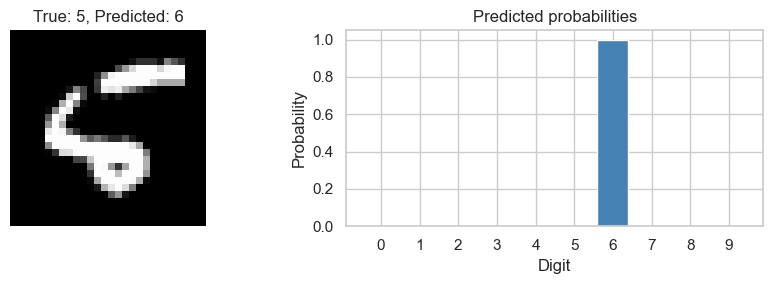

In [117]:
# Look at one misclassified image in detail
idx = wrong_idx[0]
plt.figure(figsize=(9, 3))

plt.subplot(1, 2, 1)
plt.imshow(X_test[idx], cmap="gray")
plt.title(f"True: {y_test_final[idx]}, Predicted: {y_pred_lr[idx]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.bar(range(10), proba[idx], color="steelblue")
plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Probability")
plt.title("Predicted probabilities")
plt.tight_layout()
plt.show()

In [118]:
from sklearn.neighbors import KNeighborsClassifier

# Set to None to use the full test set (slower), or e.g. 2000 for a quick run
N_TEST_KNN = None

if N_TEST_KNN is None:
    X_test_knn, y_test_knn = X_test_final, y_test_final
else:
    X_test_knn, y_test_knn = X_test_final[:N_TEST_KNN], y_test_final[:N_TEST_KNN]

print("Evaluating KNN on", len(X_test_knn), "test images")

Evaluating KNN on 10000 test images


In [119]:
k_values = [1, 3, 5, 7]
knn_results = []
knn_models = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)

    start = time.time()
    knn.fit(X_train_final, y_train_final)
    train_time = time.time() - start

    start = time.time()
    y_pred = knn.predict(X_test_knn)
    pred_time = time.time() - start

    knn_models[k] = knn
    knn_results.append({
        "K": k,
        "Accuracy": accuracy_score(y_test_knn, y_pred),
        "Precision": precision_score(y_test_knn, y_pred, average="macro"),
        "Recall": recall_score(y_test_knn, y_pred, average="macro"),
        "F1": f1_score(y_test_knn, y_pred, average="macro"),
        "Train time (s)": train_time,
        "Predict time (s)": pred_time,
    })
    print(f"K={k} done  |  accuracy={knn_results[-1]['Accuracy']:.4f}  |  predict time={pred_time:.1f}s")

knn_df = pd.DataFrame(knn_results).set_index("K")
knn_df.round(4)

K=1 done  |  accuracy=0.9691  |  predict time=16.5s
K=3 done  |  accuracy=0.9705  |  predict time=16.6s
K=5 done  |  accuracy=0.9688  |  predict time=17.2s
K=7 done  |  accuracy=0.9694  |  predict time=17.1s


,Accuracy,Precision,Recall,F1,Train time (s),Predict time (s)
K,,,,,,
1,0.9691,0.9691,0.9688,0.9689,0.0430,16.5171
3,0.9705,0.9709,0.9701,0.9704,0.0413,16.6361
5,0.9688,0.9693,0.9685,0.9687,0.0567,17.2475
7,0.9694,0.9699,0.9691,0.9694,0.0536,17.1273


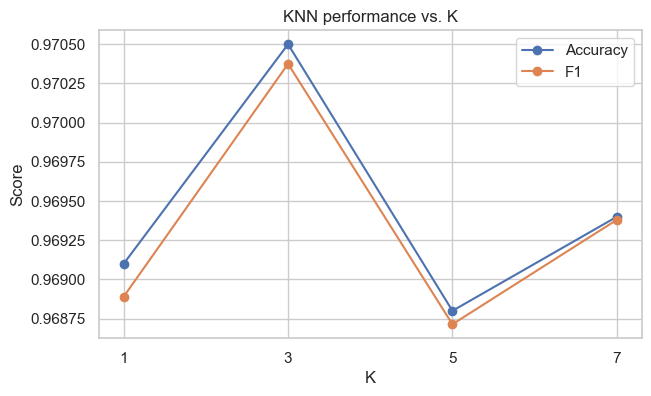

In [120]:
knn_df[["Accuracy", "F1"]].plot(marker="o", figsize=(7, 4))
plt.xticks(k_values)
plt.ylabel("Score")
plt.title("KNN performance vs. K")
plt.show()

              precision    recall  f1-score   support

           0      0.966     0.994     0.980       980
           1      0.958     0.998     0.978      1135
           2      0.982     0.965     0.974      1032
           3      0.963     0.966     0.965      1010
           4      0.975     0.967     0.971       982
           5      0.966     0.963     0.965       892
           6      0.983     0.985     0.984       958
           7      0.965     0.964     0.964      1028
           8      0.989     0.938     0.963       974
           9      0.960     0.959     0.960      1009

    accuracy                          0.971     10000
   macro avg      0.971     0.970     0.970     10000
weighted avg      0.971     0.971     0.970     10000



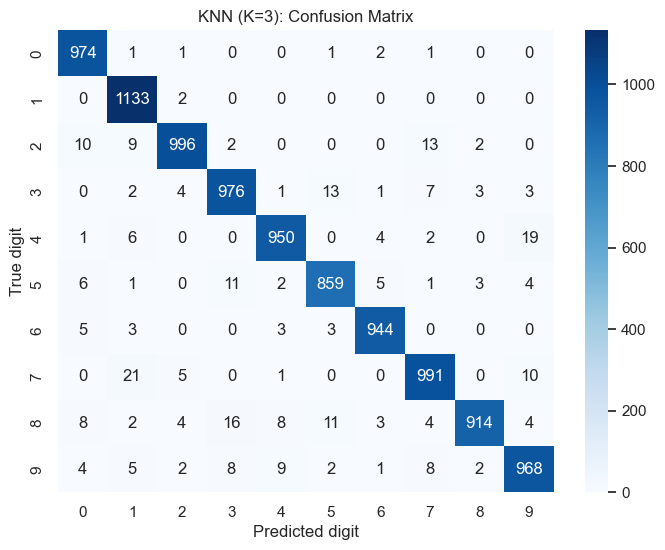

In [121]:
best_knn = knn_models[3]
y_pred_knn = best_knn.predict(X_test_knn)

print(classification_report(y_test_knn, y_pred_knn, digits=3))

cm_knn = confusion_matrix(y_test_knn, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted digit")
plt.ylabel("True digit")
plt.title("KNN (K=3): Confusion Matrix")
plt.show()

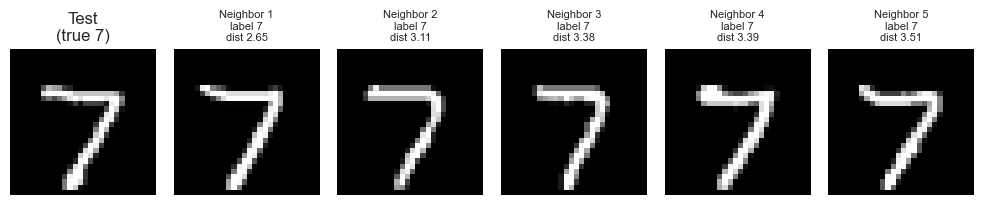

In [122]:
idx = 0
distances, neighbor_idx = knn_models[5].kneighbors(X_test_final[idx].reshape(1, -1))

plt.figure(figsize=(10, 2.5))
plt.subplot(1, 6, 1)
plt.imshow(X_test[idx], cmap="gray")
plt.title(f"Test\n(true {y_test_final[idx]})")
plt.axis("off")

for i, n_idx in enumerate(neighbor_idx[0]):
    plt.subplot(1, 6, i + 2)
    plt.imshow(X_train[n_idx], cmap="gray")
    plt.title(f"Neighbor {i+1}\nlabel {y_train_final[n_idx]}\ndist {distances[0][i]:.2f}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [123]:
from sklearn.tree import DecisionTreeClassifier

dt_full = DecisionTreeClassifier(random_state=RANDOM_STATE)

start = time.time()
dt_full.fit(X_train_final, y_train_final)
dt_train_time = time.time() - start

start = time.time()
y_pred_dt = dt_full.predict(X_test_final)
dt_pred_time = time.time() - start

print(f"Training time:   {dt_train_time:.1f} s")
print(f"Prediction time: {dt_pred_time:.3f} s")
print("Tree depth:", dt_full.get_depth())
print("Number of leaves:", dt_full.get_n_leaves())
print("Train accuracy:", accuracy_score(y_train_final, dt_full.predict(X_train_final)))
print("Test accuracy: ", accuracy_score(y_test_final, y_pred_dt))

Training time:   25.0 s
Prediction time: 0.011 s
Tree depth: 50
Number of leaves: 3936
Train accuracy: 1.0
Test accuracy:  0.8754


           Train accuracy  Test accuracy
max_depth                               
1                  0.1982         0.1994
2                  0.3418         0.3447
3                  0.4915         0.4953
5                  0.6723         0.6747
8                  0.8263         0.8183
10                 0.8995         0.8663
15                 0.9844         0.8803
20                 0.9950         0.8818
30                 0.9983         0.8773


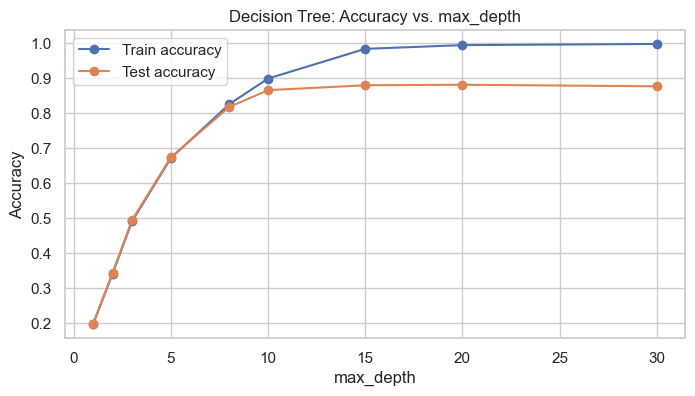

In [124]:
depths = [1, 2, 3, 5, 8, 10, 15, 20, 30]
depth_results = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    tree.fit(X_train_final, y_train_final)
    depth_results.append({
        "max_depth": d,
        "Train accuracy": tree.score(X_train_final, y_train_final),
        "Test accuracy": tree.score(X_test_final, y_test_final),
    })

depth_df = pd.DataFrame(depth_results).set_index("max_depth")
print(depth_df.round(4))

depth_df.plot(marker="o", figsize=(8, 4))
plt.ylabel("Accuracy")
plt.title("Decision Tree: Accuracy vs. max_depth")
plt.show()

In [125]:
dt = DecisionTreeClassifier(max_depth=15, random_state=RANDOM_STATE)

start = time.time()
dt.fit(X_train_final, y_train_final)
dt_train_time = time.time() - start

start = time.time()
y_pred_dt = dt.predict(X_test_final)
dt_pred_time = time.time() - start

print(f"Accuracy: {accuracy_score(y_test_final, y_pred_dt):.4f}")
print(f"Training time: {dt_train_time:.1f}s | Prediction time: {dt_pred_time:.3f}s\n")
print(classification_report(y_test_final, y_pred_dt, digits=3))

Accuracy: 0.8803
Training time: 14.4s | Prediction time: 0.009s

              precision    recall  f1-score   support

           0      0.903     0.944     0.923       980
           1      0.951     0.962     0.957      1135
           2      0.874     0.864     0.869      1032
           3      0.838     0.857     0.848      1010
           4      0.873     0.874     0.873       982
           5      0.846     0.831     0.838       892
           6      0.904     0.882     0.893       958
           7      0.907     0.905     0.906      1028
           8      0.836     0.801     0.818       974
           9      0.855     0.866     0.861      1009

    accuracy                          0.880     10000
   macro avg      0.879     0.879     0.879     10000
weighted avg      0.880     0.880     0.880     10000



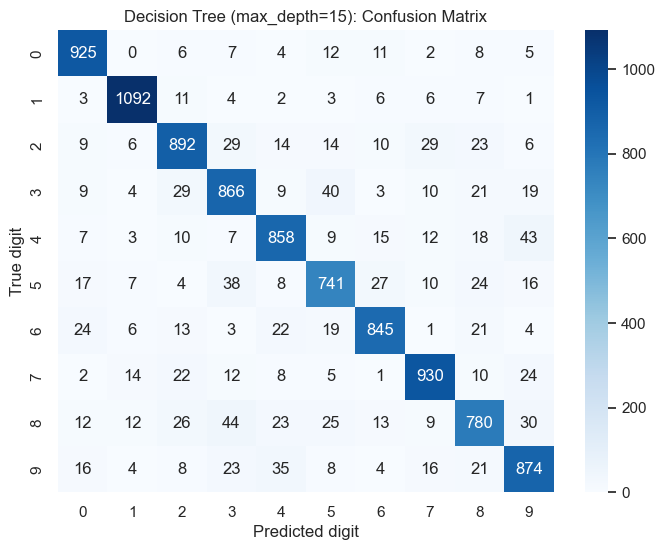

In [126]:
cm_dt = confusion_matrix(y_test_final, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted digit")
plt.ylabel("True digit")
plt.title("Decision Tree (max_depth=15): Confusion Matrix")
plt.show()

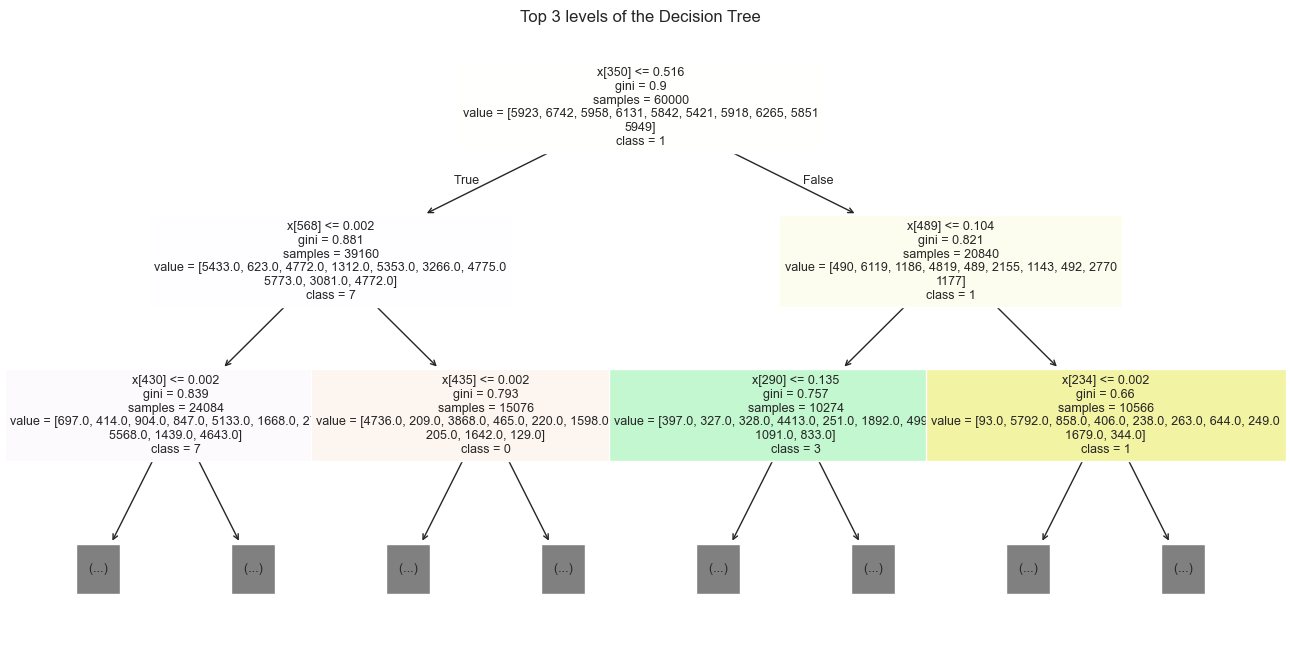

In [127]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 8))
plot_tree(dt, max_depth=2, filled=True, fontsize=9,
          class_names=[str(i) for i in range(10)])
plt.title("Top 3 levels of the Decision Tree")
plt.show()

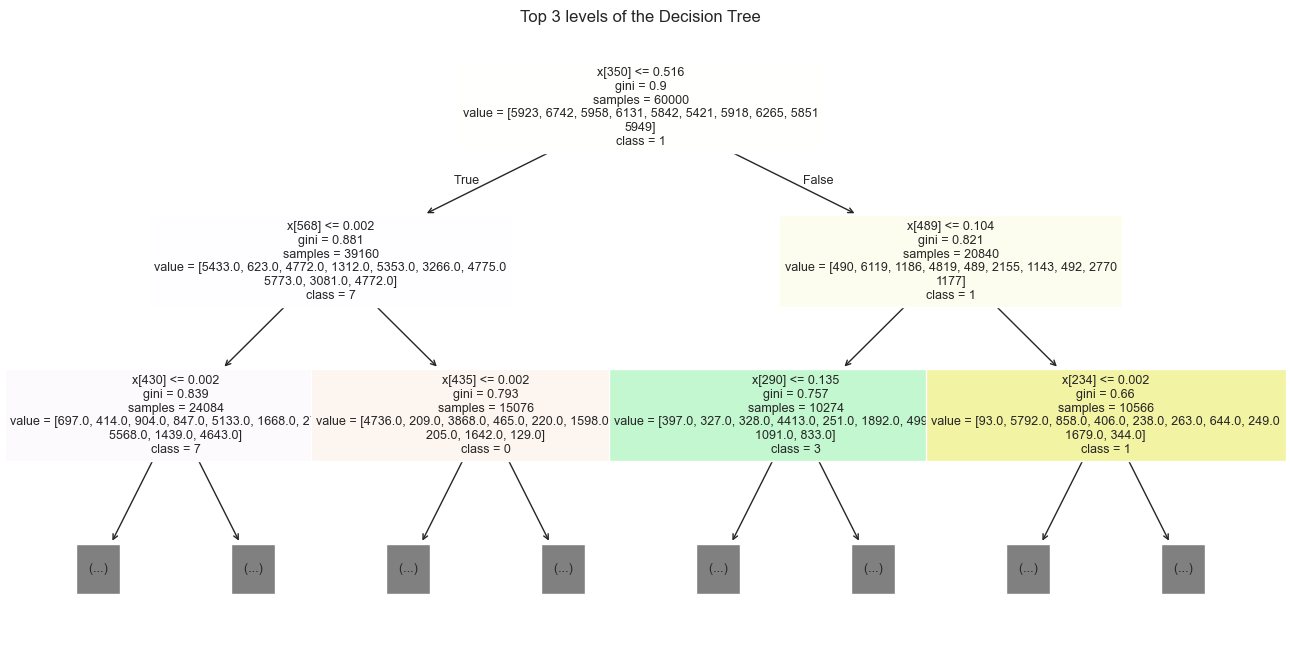

In [128]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 8))
plot_tree(dt, max_depth=2, filled=True, fontsize=9,
          class_names=[str(i) for i in range(10)])
plt.title("Top 3 levels of the Decision Tree")
plt.show()

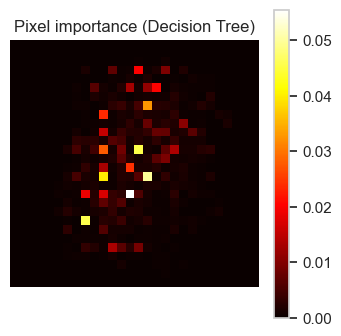

In [129]:
importances = dt.feature_importances_.reshape(28, 28)

plt.figure(figsize=(4, 4))
plt.imshow(importances, cmap="hot")
plt.title("Pixel importance (Decision Tree)")
plt.colorbar()
plt.axis("off")
plt.show()

In [130]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

start = time.time()
rf.fit(X_train_final, y_train_final)
rf_train_time = time.time() - start

start = time.time()
y_pred_rf = rf.predict(X_test_final)
rf_pred_time = time.time() - start

print(f"Training time:   {rf_train_time:.1f} s")
print(f"Prediction time: {rf_pred_time:.2f} s")

Training time:   14.7 s
Prediction time: 0.21 s


In [131]:
acc = accuracy_score(y_test_final, y_pred_rf)
prec = precision_score(y_test_final, y_pred_rf, average="macro")
rec = recall_score(y_test_final, y_pred_rf, average="macro")
f1 = f1_score(y_test_final, y_pred_rf, average="macro")

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\n", classification_report(y_test_final, y_pred_rf, digits=3))

Accuracy:  0.9704
Precision: 0.9703
Recall:    0.9701
F1-score:  0.9702

               precision    recall  f1-score   support

           0      0.968     0.991     0.979       980
           1      0.988     0.993     0.990      1135
           2      0.962     0.971     0.966      1032
           3      0.963     0.962     0.963      1010
           4      0.974     0.973     0.973       982
           5      0.976     0.964     0.970       892
           6      0.976     0.978     0.977       958
           7      0.972     0.962     0.967      1028
           8      0.962     0.955     0.958       974
           9      0.962     0.952     0.957      1009

    accuracy                          0.970     10000
   macro avg      0.970     0.970     0.970     10000
weighted avg      0.970     0.970     0.970     10000



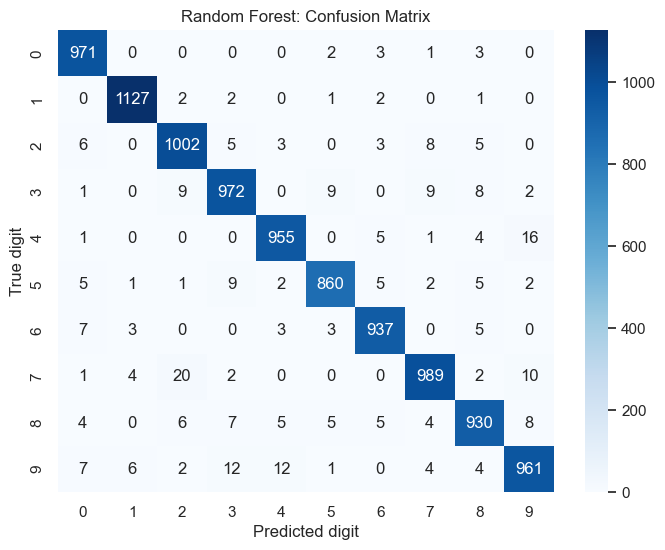

In [132]:
cm_rf = confusion_matrix(y_test_final, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted digit")
plt.ylabel("True digit")
plt.title("Random Forest: Confusion Matrix")
plt.show()

In [133]:
print("Random Forest train accuracy:", rf.score(X_train_final, y_train_final))
print("Random Forest test accuracy: ", rf.score(X_test_final, y_test_final))

Random Forest train accuracy: 1.0
Random Forest test accuracy:  0.9704


              Test accuracy
n_estimators               
1                    0.8245
5                    0.9244
10                   0.9492
25                   0.9627
50                   0.9668
100                  0.9704


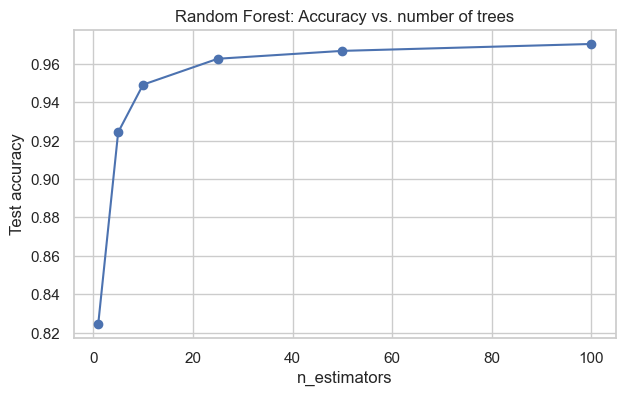

In [134]:
n_trees_list = [1, 5, 10, 25, 50, 100]
tree_results = []

for n in n_trees_list:
    model = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_train_final, y_train_final)
    tree_results.append({
        "n_estimators": n,
        "Test accuracy": model.score(X_test_final, y_test_final),
    })

trees_df = pd.DataFrame(tree_results).set_index("n_estimators")
print(trees_df.round(4))

trees_df.plot(marker="o", figsize=(7, 4), legend=False)
plt.ylabel("Test accuracy")
plt.title("Random Forest: Accuracy vs. number of trees")
plt.show()

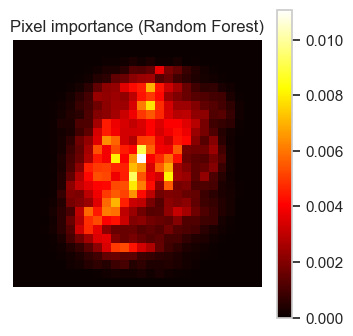

In [135]:
importances = rf.feature_importances_.reshape(28, 28)

plt.figure(figsize=(4, 4))
plt.imshow(importances, cmap="hot")
plt.title("Pixel importance (Random Forest)")
plt.colorbar()
plt.axis("off")
plt.show()

In [136]:
from sklearn.svm import SVC

# Number of training images for SVM. Set to None for the full 60,000 (slow!).
N_TRAIN_SVM = 10000

if N_TRAIN_SVM is None:
    X_train_svm, y_train_svm = X_train_final, y_train_final
else:
    rng = np.random.RandomState(RANDOM_STATE)
    subset_idx = rng.choice(len(X_train_final), size=N_TRAIN_SVM, replace=False)
    X_train_svm, y_train_svm = X_train_final[subset_idx], y_train_final[subset_idx]

print("Training SVM on", len(X_train_svm), "images")
print("Class counts in subset:", np.bincount(y_train_svm))

Training SVM on 10000 images
Class counts in subset: [ 984 1093  994 1000  980  919  981 1060  979 1010]


In [137]:
svm = SVC(kernel="rbf", C=5, gamma="scale", probability=False, random_state=RANDOM_STATE)

start = time.time()
svm.fit(X_train_svm, y_train_svm)
svm_train_time = time.time() - start

start = time.time()
y_pred_svm = svm.predict(X_test_final)
svm_pred_time = time.time() - start

print(f"Training time:   {svm_train_time:.1f} s")
print(f"Prediction time: {svm_pred_time:.1f} s")
print("Support vectors per class:", svm.n_support_)
print("Total support vectors:", svm.n_support_.sum(), "out of", len(X_train_svm))

Training time:   12.4 s
Prediction time: 28.3 s
Support vectors per class: [285 191 407 419 403 473 303 335 503 465]
Total support vectors: 3784 out of 10000


In [138]:
acc = accuracy_score(y_test_final, y_pred_svm)
prec = precision_score(y_test_final, y_pred_svm, average="macro")
rec = recall_score(y_test_final, y_pred_svm, average="macro")
f1 = f1_score(y_test_final, y_pred_svm, average="macro")

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}\n")

print(classification_report(y_test_final, y_pred_svm, digits=3))

Accuracy:  0.9701
Precision: 0.9699
Recall:    0.9697
F1-score:  0.9698

              precision    recall  f1-score   support

           0      0.968     0.991     0.979       980
           1      0.989     0.993     0.991      1135
           2      0.970     0.964     0.967      1032
           3      0.964     0.966     0.965      1010
           4      0.967     0.968     0.968       982
           5      0.971     0.955     0.963       892
           6      0.970     0.982     0.976       958
           7      0.967     0.966     0.966      1028
           8      0.969     0.957     0.963       974
           9      0.963     0.954     0.959      1009

    accuracy                          0.970     10000
   macro avg      0.970     0.970     0.970     10000
weighted avg      0.970     0.970     0.970     10000



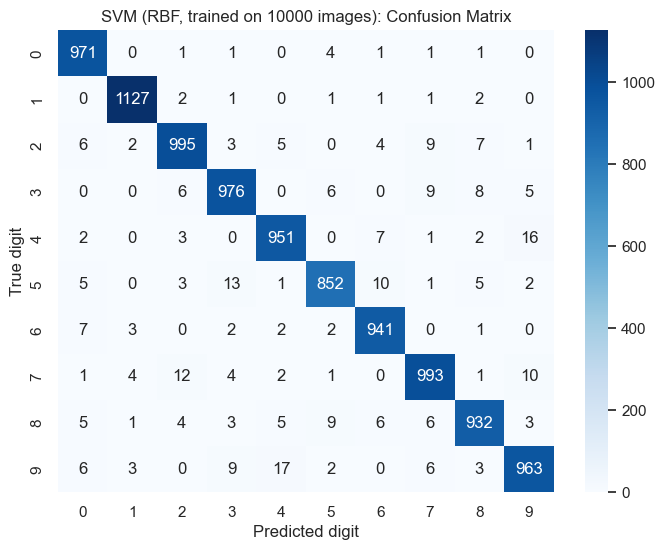

In [139]:
cm_svm = confusion_matrix(y_test_final, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted digit")
plt.ylabel("True digit")
plt.title(f"SVM (RBF, trained on {len(X_train_svm)} images): Confusion Matrix")
plt.show()

In [140]:
sizes = [1000, 2500, 5000, 10000]
size_results = []

for n in sizes:
    idx = np.random.RandomState(RANDOM_STATE).choice(len(X_train_final), size=n, replace=False)
    model = SVC(kernel="rbf", C=5, gamma="scale")

    start = time.time()
    model.fit(X_train_final[idx], y_train_final[idx])
    t = time.time() - start

    size_results.append({
        "Training size": n,
        "Test accuracy": model.score(X_test_final, y_test_final),
        "Train time (s)": t,
    })

pd.DataFrame(size_results).set_index("Training size").round(3)

,Test accuracy,Train time (s)
Training size,,
1000,0.933,0.215
2500,0.950,0.770
5000,0.960,2.555
10000,0.970,10.145


In [141]:
def evaluate_model(name, y_true, y_pred, train_time, pred_time, note=""):
    """Return a dict of metrics for one model (macro-averaged)."""
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro"),
        "Recall": recall_score(y_true, y_pred, average="macro"),
        "F1": f1_score(y_true, y_pred, average="macro"),
        "Train time (s)": train_time,
        "Predict time (s)": pred_time,
        "Notes": note,
    }

In [142]:
# KNN: we chose K=3 earlier; pull its timings from knn_df
knn_train = knn_df.loc[3, "Train time (s)"]
knn_pred = knn_df.loc[3, "Predict time (s)"]

comparison_rows = [
    evaluate_model("Logistic Regression", y_test_final, y_pred_lr,
                   lr_train_time, lr_pred_time, "Linear baseline"),
    evaluate_model("KNN (K=3)", y_test_knn, y_pred_knn,
                   knn_train, knn_pred, "No real training; slow prediction"),
    evaluate_model("Decision Tree (depth 15)", y_test_final, y_pred_dt,
                   dt_train_time, dt_pred_time, "Single tree; overfits"),
    evaluate_model("Random Forest (100 trees)", y_test_final, y_pred_rf,
                   rf_train_time, rf_pred_time, "Ensemble of trees"),
    evaluate_model(f"SVM (RBF, {len(X_train_svm):,} train imgs)", y_test_final, y_pred_svm,
                   svm_train_time, svm_pred_time, "Trained on a subset"),
]

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
comparison_df.round(4)

,Accuracy,Precision,Recall,F1,Train time (s),Predict time (s),Notes
Model,,,,,,,
Logistic Regression,0.9261,0.9251,0.9250,0.9250,29.0754,0.0478,Linear baseline
KNN (K=3),0.9705,0.9709,0.9701,0.9704,0.0413,16.6361,No real training; slow prediction
Decision Tree (depth 15),0.8803,0.8788,0.8786,0.8786,14.3844,0.0091,Single tree; overfits
Random Forest (100 trees),0.9704,0.9703,0.9701,0.9702,14.7140,0.2057,Ensemble of trees
"SVM (RBF, 10,000 train imgs)",0.9701,0.9699,0.9697,0.9698,12.4438,28.2915,Trained on a subset


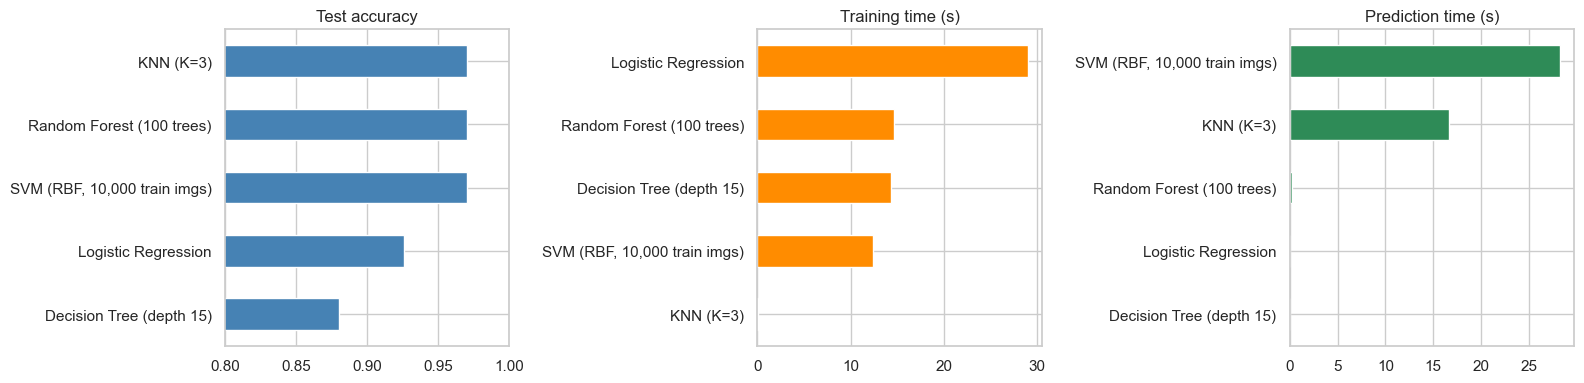

In [143]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

comparison_df["Accuracy"].sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_xlim(0.8, 1.0)
axes[0].set_title("Test accuracy")

comparison_df["Train time (s)"].sort_values().plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Training time (s)")

comparison_df["Predict time (s)"].sort_values().plot(kind="barh", ax=axes[2], color="seagreen")
axes[2].set_title("Prediction time (s)")

for ax in axes:
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [144]:
def get_errors(y_true, y_pred, proba):
    """Return indices of mistakes, sorted by how confident the model was (most confident first)."""
    wrong = np.where(y_pred != y_true)[0]
    confidence = proba.max(axis=1)
    order = np.argsort(confidence[wrong])[::-1]
    return wrong[order]

def show_errors(images, y_true, y_pred, proba, indices, title, n=12):
    n = min(n, len(indices))
    fig, axes = plt.subplots(2, 6, figsize=(14, 5))
    for ax, idx in zip(axes.flat, indices[:n]):
        ax.imshow(images[idx], cmap="gray")
        conf = proba[idx].max()
        ax.set_title(f"True: {y_true[idx]}  Pred: {y_pred[idx]}\nconf: {conf:.2f}", fontsize=9)
        ax.axis("off")
    for ax in list(axes.flat)[n:]:
        ax.axis("off")
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

Random Forest made 296 errors out of 10000 test images (2.96%)


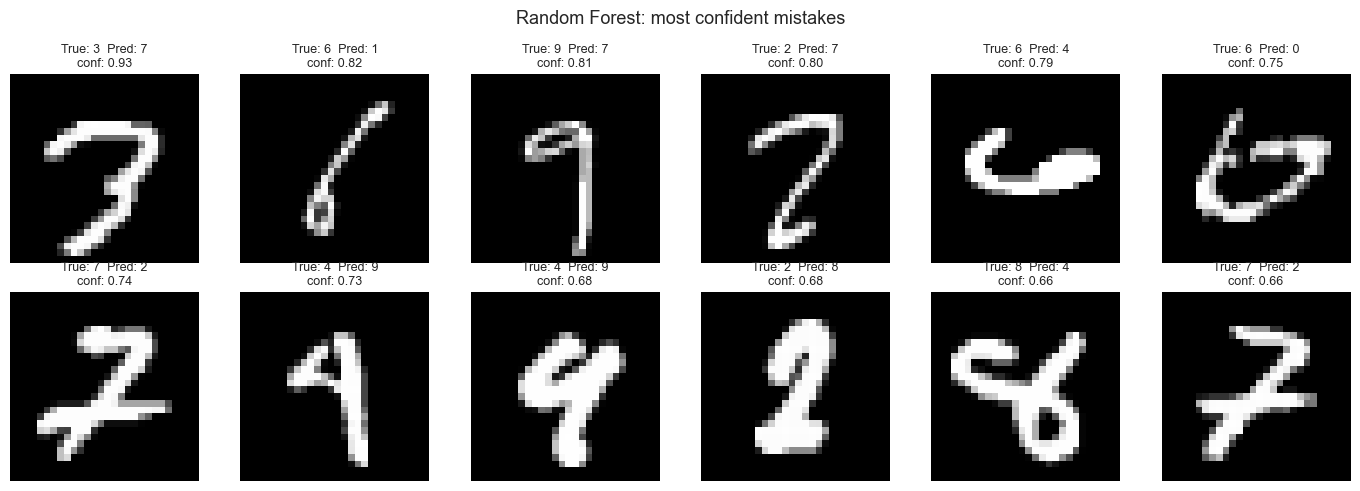

In [145]:
proba_rf = rf.predict_proba(X_test_final)
errors_rf = get_errors(y_test_final, y_pred_rf, proba_rf)

print(f"Random Forest made {len(errors_rf)} errors out of {len(y_test_final)} test images "
      f"({len(errors_rf)/len(y_test_final):.2%})")

show_errors(X_test, y_test_final, y_pred_rf, proba_rf, errors_rf,
            "Random Forest: most confident mistakes")

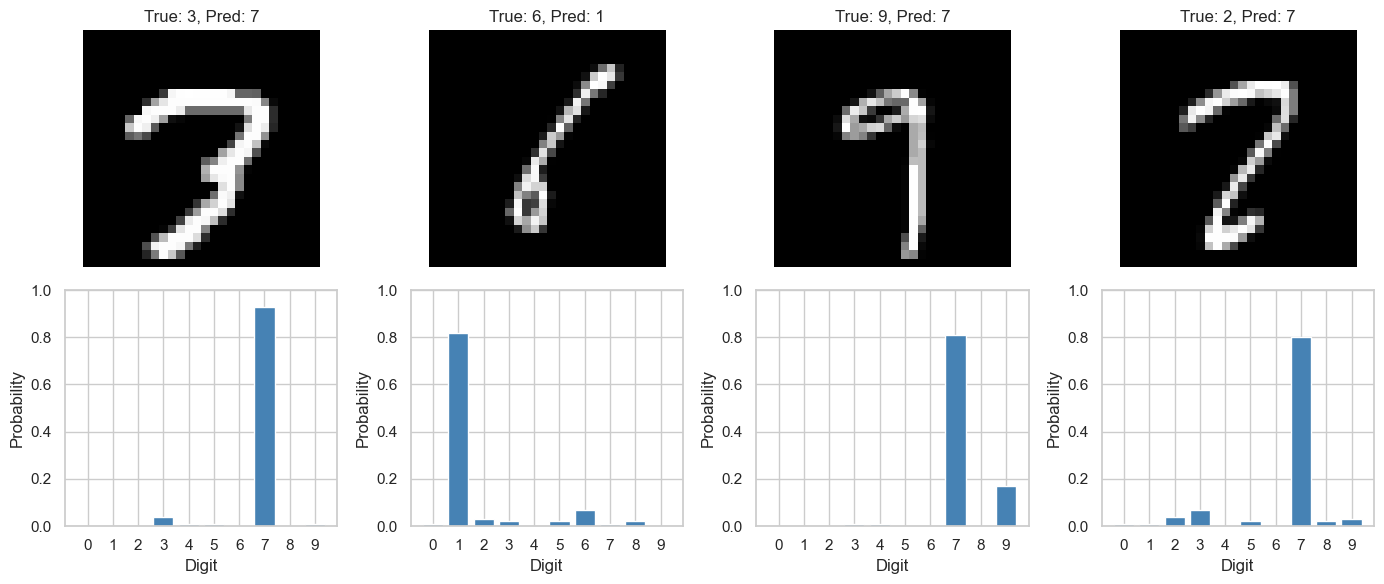

In [146]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for col, idx in enumerate(errors_rf[:4]):
    axes[0, col].imshow(X_test[idx], cmap="gray")
    axes[0, col].set_title(f"True: {y_test_final[idx]}, Pred: {y_pred_rf[idx]}")
    axes[0, col].axis("off")

    axes[1, col].bar(range(10), proba_rf[idx], color="steelblue")
    axes[1, col].set_xticks(range(10))
    axes[1, col].set_ylim(0, 1)
    axes[1, col].set_xlabel("Digit")
    axes[1, col].set_ylabel("Probability")

plt.tight_layout()
plt.show()

In [147]:
top2 = np.argsort(proba_rf, axis=1)[:, -2:]
top2_acc = np.mean([y_test_final[i] in top2[i] for i in range(len(y_test_final))])
print(f"Top-1 accuracy: {accuracy_score(y_test_final, y_pred_rf):.4f}")
print(f"Top-2 accuracy: {top2_acc:.4f}")

Top-1 accuracy: 0.9704
Top-2 accuracy: 0.9908


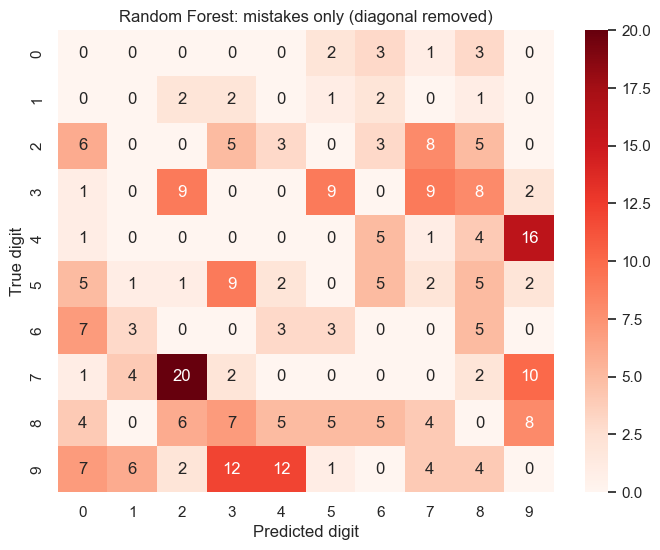

In [148]:
cm_rf = confusion_matrix(y_test_final, y_pred_rf)

# Zero the diagonal so we only see mistakes
cm_errors = cm_rf.copy()
np.fill_diagonal(cm_errors, 0)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_errors, annot=True, fmt="d", cmap="Reds")
plt.xlabel("Predicted digit")
plt.ylabel("True digit")
plt.title("Random Forest: mistakes only (diagonal removed)")
plt.show()

In [149]:
pairs = []
for true_digit in range(10):
    for pred_digit in range(10):
        if true_digit != pred_digit:
            pairs.append((true_digit, pred_digit, cm_rf[true_digit, pred_digit]))

top_confusions = (pd.DataFrame(pairs, columns=["True", "Predicted", "Count"])
                    .sort_values("Count", ascending=False)
                    .head(10)
                    .reset_index(drop=True))
top_confusions

,True,Predicted,Count
0,7,2,20
1,4,9,16
2,9,4,12
3,9,3,12
4,7,9,10
5,3,5,9
6,3,2,9
7,5,3,9
8,3,7,9
9,2,7,8


In [150]:
per_class_recall = cm_rf.diagonal() / cm_rf.sum(axis=1)
per_class_precision = cm_rf.diagonal() / cm_rf.sum(axis=0)

class_df = pd.DataFrame({
    "Recall": per_class_recall,
    "Precision": per_class_precision,
}, index=range(10))
class_df.round(3)

,Recall,Precision
0,0.991,0.968
1,0.993,0.988
2,0.971,0.962
3,0.962,0.963
4,0.973,0.974
5,0.964,0.976
6,0.978,0.976
7,0.962,0.972
8,0.955,0.962
9,0.952,0.962


KNN made 295 errors out of 10000 (2.95%)


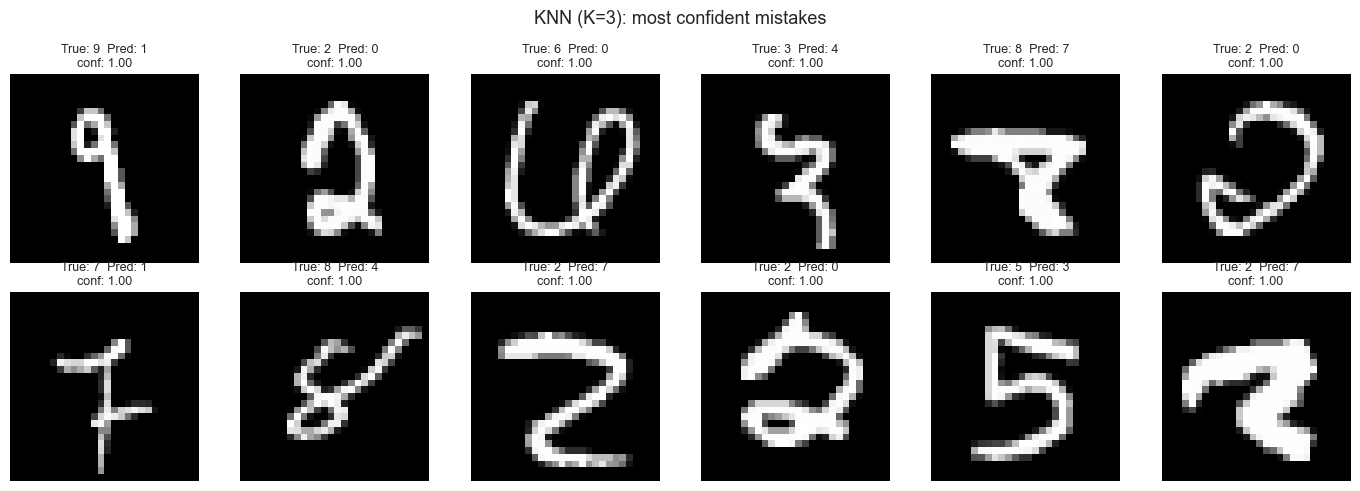

In [151]:
proba_knn = knn_models[3].predict_proba(X_test_knn)
errors_knn = get_errors(y_test_knn, y_pred_knn, proba_knn)

print(f"KNN made {len(errors_knn)} errors out of {len(y_test_knn)} "
      f"({len(errors_knn)/len(y_test_knn):.2%})")

show_errors(X_test[:len(X_test_knn)], y_test_knn, y_pred_knn, proba_knn,
            errors_knn, "KNN (K=3): most confident mistakes")

In [152]:
n = len(y_test_knn)
wrong_rf = set(np.where(y_pred_rf[:n] != y_test_final[:n])[0])
wrong_knn = set(errors_knn)

both = wrong_rf & wrong_knn
print("Wrong in RF:", len(wrong_rf), "| Wrong in KNN:", len(wrong_knn), "| Wrong in both:", len(both))

Wrong in RF: 296 | Wrong in KNN: 295 | Wrong in both: 164


In [153]:
from sklearn.decomposition import PCA

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_final)

print("Number of components:", pca_full.n_components_)
print("Variance explained by PC1:", pca_full.explained_variance_ratio_[0].round(4))
print("Variance explained by PC2:", pca_full.explained_variance_ratio_[1].round(4))

Number of components: 784
Variance explained by PC1: 0.097
Variance explained by PC2: 0.071


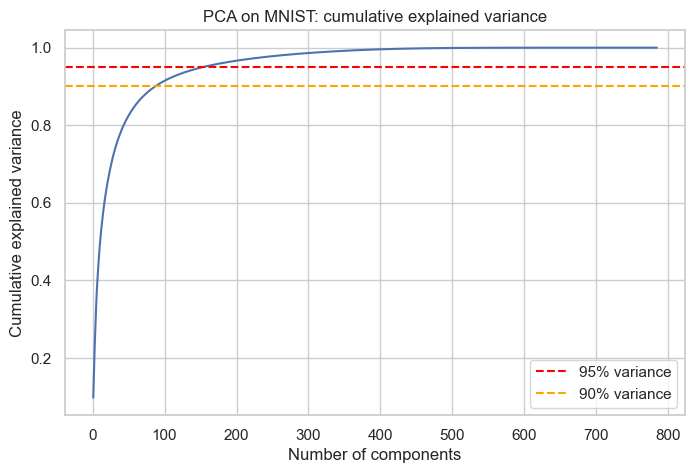

80% variance needs 44 components
90% variance needs 87 components
95% variance needs 154 components
99% variance needs 331 components


In [154]:
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var)
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.axhline(0.90, color="orange", linestyle="--", label="90% variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA on MNIST: cumulative explained variance")
plt.legend()
plt.grid(True)
plt.show()

for target in [0.80, 0.90, 0.95, 0.99]:
    k = np.argmax(cum_var >= target) + 1
    print(f"{int(target*100)}% variance needs {k} components")

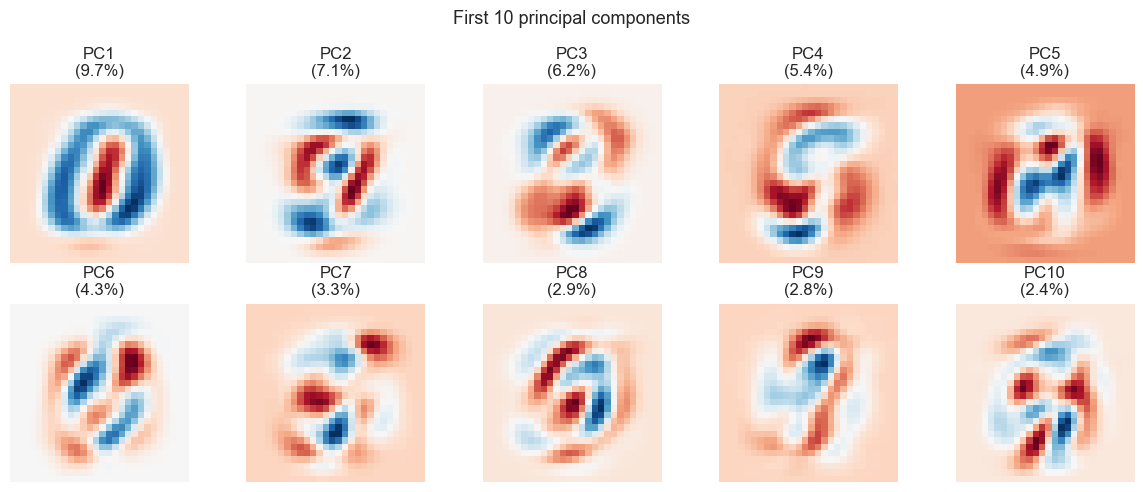

In [155]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca_full.components_[i].reshape(28, 28), cmap="RdBu")
    ax.set_title(f"PC{i+1}\n({pca_full.explained_variance_ratio_[i]:.1%})")
    ax.axis("off")
plt.suptitle("First 10 principal components", fontsize=13)
plt.tight_layout()
plt.show()

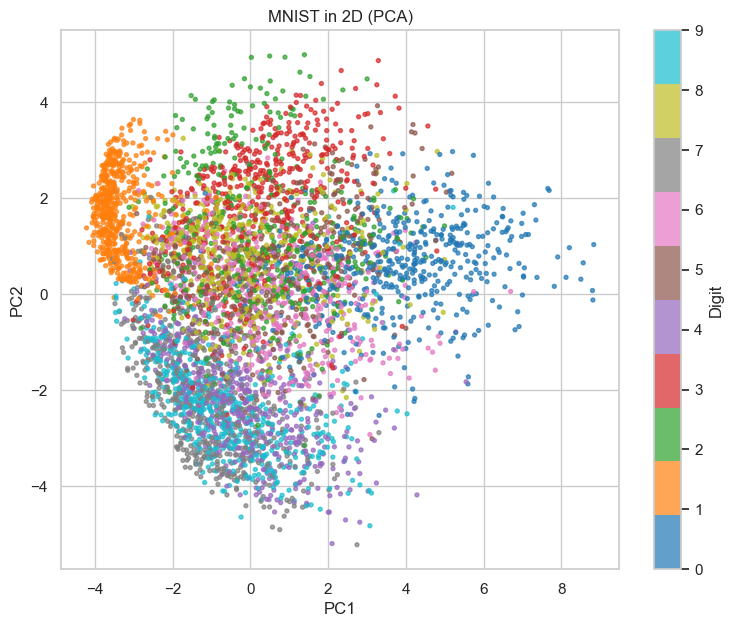

In [156]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca2 = pca_2d.fit_transform(X_train_final)

# Plot a random subset so the chart stays readable and fast
rng = np.random.RandomState(RANDOM_STATE)
sample = rng.choice(len(X_train_pca2), size=5000, replace=False)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_train_pca2[sample, 0], X_train_pca2[sample, 1],
                      c=y_train_final[sample], cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label="Digit")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("MNIST in 2D (PCA)")
plt.show()

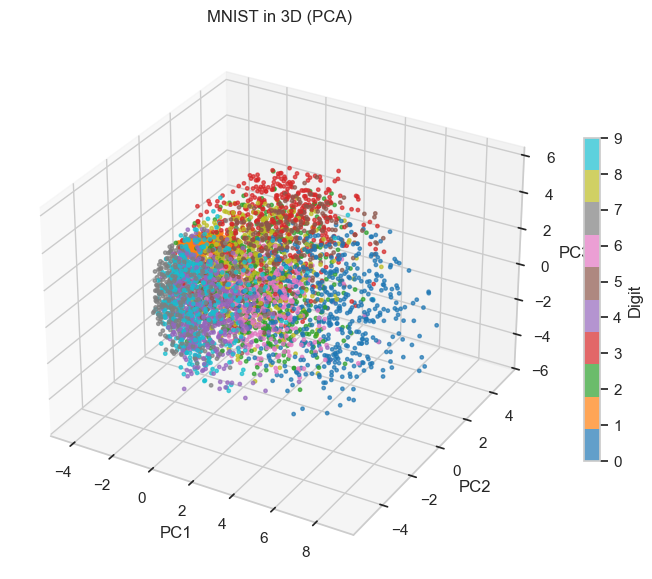

In [157]:
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_train_pca3 = pca_3d.fit_transform(X_train_final)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(X_train_pca3[sample, 0], X_train_pca3[sample, 1], X_train_pca3[sample, 2],
               c=y_train_final[sample], cmap="tab10", s=6, alpha=0.7)
fig.colorbar(p, ticks=range(10), label="Digit", shrink=0.6)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
ax.set_title("MNIST in 3D (PCA)")
plt.show()

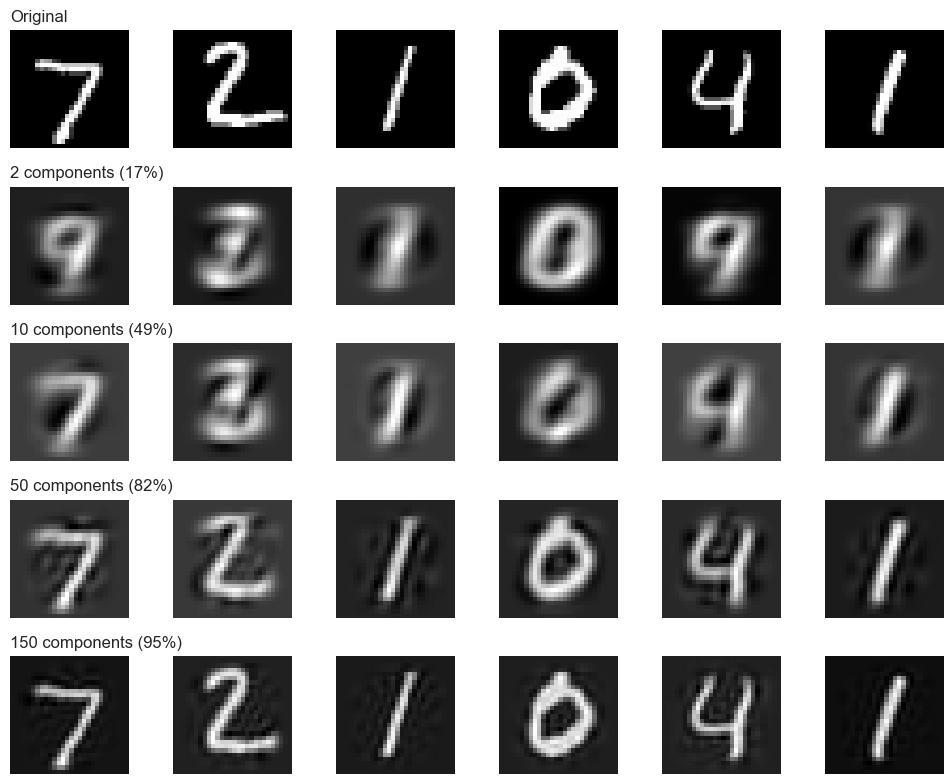

In [158]:
n_show = 6
ks = [2, 10, 50, 150]

fig, axes = plt.subplots(len(ks) + 1, n_show, figsize=(10, 8))

for col in range(n_show):
    axes[0, col].imshow(X_test_final[col].reshape(28, 28), cmap="gray")
    axes[0, col].axis("off")
axes[0, 0].set_title("Original", loc="left")

for row, k in enumerate(ks, start=1):
    pca_k = PCA(n_components=k, random_state=RANDOM_STATE).fit(X_train_final)
    reconstructed = pca_k.inverse_transform(pca_k.transform(X_test_final[:n_show]))
    for col in range(n_show):
        axes[row, col].imshow(reconstructed[col].reshape(28, 28), cmap="gray")
        axes[row, col].axis("off")
    axes[row, 0].set_title(f"{k} components ({pca_k.explained_variance_ratio_.sum():.0%})", loc="left")

plt.tight_layout()
plt.show()

In [159]:
for k in [2, 10, 50, 150, 400]:
    pca_k = PCA(n_components=k, random_state=RANDOM_STATE).fit(X_train_final)
    recon = pca_k.inverse_transform(pca_k.transform(X_test_final))
    mse = np.mean((X_test_final - recon) ** 2)
    print(f"{k:>3} components | variance kept: {pca_k.explained_variance_ratio_.sum():.1%} | reconstruction MSE: {mse:.5f}")

  2 components | variance kept: 16.8% | reconstruction MSE: 0.05567
 10 components | variance kept: 48.8% | reconstruction MSE: 0.03407
 50 components | variance kept: 82.5% | reconstruction MSE: 0.01149
150 components | variance kept: 94.8% | reconstruction MSE: 0.00342
400 components | variance kept: 99.6% | reconstruction MSE: 0.00027


In [160]:
pca_50 = PCA(n_components=50, random_state=RANDOM_STATE)
X_train_p50 = pca_50.fit_transform(X_train_final)
X_test_p50 = pca_50.transform(X_test_final)      # transform only, never refit

knn_pca = KNeighborsClassifier(n_neighbors=3, n_jobs=-1).fit(X_train_p50, y_train_final)

start = time.time()
pred = knn_pca.predict(X_test_p50)
print(f"KNN on 50 PCA features | accuracy: {accuracy_score(y_test_final, pred):.4f} | predict time: {time.time()-start:.1f}s")

KNN on 50 PCA features | accuracy: 0.9752 | predict time: 2.4s


In [161]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

N_TUNE = 10000
rng = np.random.RandomState(RANDOM_STATE)
tune_idx = rng.choice(len(X_train_final), size=N_TUNE, replace=False)
X_tune, y_tune = X_train_final[tune_idx], y_train_final[tune_idx]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [162]:
param_grid_svm = {
    "C": [1, 5, 10],
    "gamma": [0.005, 0.02, "scale"],
}

grid_svm = GridSearchCV(
    SVC(kernel="rbf"),
    param_grid=param_grid_svm,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

start = time.time()
grid_svm.fit(X_tune, y_tune)
print(f"Search time: {time.time() - start:.0f} s")

print("Best parameters:", grid_svm.best_params_)
print(f"Best CV accuracy: {grid_svm.best_score_:.4f}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Search time: 294 s
Best parameters: {'C': 5, 'gamma': 0.02}
Best CV accuracy: 0.9651


In [163]:
results_svm = pd.DataFrame(grid_svm.cv_results_)
cols = ["param_C", "param_gamma", "mean_test_score", "std_test_score", "mean_fit_time"]
results_svm[cols].sort_values("mean_test_score", ascending=False).round(4)

,param_C,param_gamma,mean_test_score,std_test_score,mean_fit_time
4,5,0.02,0.9651,0.0031,48.2752
7,10,0.02,0.9649,0.0032,44.8241
5,5,scale,0.9631,0.0031,34.9962
8,10,scale,0.9625,0.0028,33.2013
1,1,0.02,0.9616,0.0026,56.6099
2,1,scale,0.9567,0.0025,47.0345
6,10,0.005,0.9520,0.0039,23.2296
3,5,0.005,0.9516,0.0037,31.0740
0,1,0.005,0.9393,0.0026,47.6884


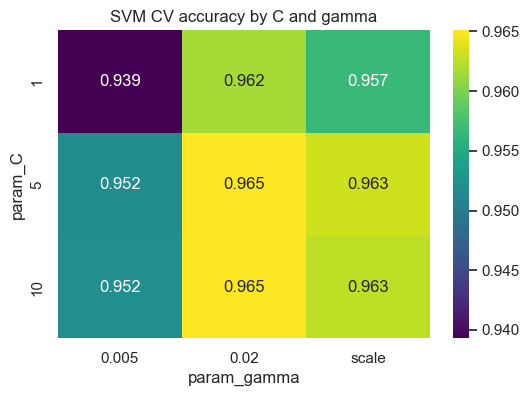

In [164]:
pivot = results_svm.pivot(index="param_C", columns="param_gamma", values="mean_test_score").astype(float)
plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("SVM CV accuracy by C and gamma")
plt.show()

In [165]:
from scipy.stats import randint

param_dist_rf = {
    "n_estimators": randint(50, 200),
    "max_depth": [None, 20, 30],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.2],
}

random_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=8,
    cv=cv,
    scoring="accuracy",
    random_state=RANDOM_STATE,
    verbose=1,
)

start = time.time()
random_rf.fit(X_tune, y_tune)
print(f"Search time: {time.time() - start:.0f} s")

print("Best parameters:", random_rf.best_params_)
print(f"Best CV accuracy: {random_rf.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Search time: 1058 s
Best parameters: {'max_depth': 30, 'max_features': 0.2, 'min_samples_leaf': 1, 'n_estimators': 149}
Best CV accuracy: 0.9411


In [166]:
results_rf = pd.DataFrame(random_rf.cv_results_)
cols = ["param_n_estimators", "param_max_depth", "param_min_samples_leaf",
        "param_max_features", "mean_test_score", "std_test_score"]
results_rf[cols].sort_values("mean_test_score", ascending=False).round(4)

,param_n_estimators,param_max_depth,param_min_samples_leaf,param_max_features,mean_test_score,std_test_score
3,149,30,1,0.2,0.9411,0.0039
1,70,30,1,0.2,0.9389,0.0070
0,64,30,1,0.2,0.9379,0.0069
7,98,None,1,0.2,0.9376,0.0044
4,51,30,1,0.2,0.9375,0.0064
6,71,None,2,0.2,0.9365,0.0075
5,70,20,2,0.2,0.9364,0.0065
2,124,30,4,0.2,0.9336,0.0041


In [183]:
# Option 1 (fast): SVM on a 20,000-image training subset
# Option 2 (slow but best): set N_FINAL = None for all 60,000
N_FINAL = 20000

if N_FINAL is None:
    X_final_train, y_final_train = X_train_final, y_train_final
else:
    idx = np.random.RandomState(RANDOM_STATE).choice(len(X_train_final), size=N_FINAL, replace=False)
    X_final_train, y_final_train = X_train_final[idx], y_train_final[idx]

best_svm = SVC(kernel="rbf", **grid_svm.best_params_)

start = time.time()
best_svm.fit(X_final_train, y_final_train)
print(f"Final SVM trained on {len(X_final_train):,} images in {time.time()-start:.0f} s")

Final SVM trained on 20,000 images in 46 s


In [184]:
final_model = best_svm      # or: random_rf.best_estimator_
final_model_name = "Tuned SVM (RBF)"
print("Final model:", final_model_name)
print("Hyperparameters:", final_model.get_params())

Final model: Tuned SVM (RBF)
Hyperparameters: {'C': 5, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 0.02, 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [185]:
start = time.time()
y_pred_final = final_model.predict(X_test_final)
final_pred_time = time.time() - start

final_acc = accuracy_score(y_test_final, y_pred_final)
final_prec = precision_score(y_test_final, y_pred_final, average="macro")
final_rec = recall_score(y_test_final, y_pred_final, average="macro")
final_f1 = f1_score(y_test_final, y_pred_final, average="macro")

print(f"Final model: {final_model_name}")
print(f"Test accuracy:  {final_acc:.4f}")
print(f"Test precision: {final_prec:.4f}")
print(f"Test recall:    {final_rec:.4f}")
print(f"Test F1-score:  {final_f1:.4f}")
print(f"Prediction time on {len(X_test_final):,} images: {final_pred_time:.1f} s")

Final model: Tuned SVM (RBF)
Test accuracy:  0.9790
Test precision: 0.9789
Test recall:    0.9788
Test F1-score:  0.9788
Prediction time on 10,000 images: 40.3 s


In [186]:
print(classification_report(y_test_final, y_pred_final, digits=3))

              precision    recall  f1-score   support

           0      0.979     0.992     0.985       980
           1      0.992     0.993     0.993      1135
           2      0.981     0.975     0.978      1032
           3      0.972     0.985     0.978      1010
           4      0.975     0.975     0.975       982
           5      0.984     0.971     0.977       892
           6      0.984     0.985     0.985       958
           7      0.977     0.976     0.976      1028
           8      0.976     0.974     0.975       974
           9      0.970     0.962     0.966      1009

    accuracy                          0.979     10000
   macro avg      0.979     0.979     0.979     10000
weighted avg      0.979     0.979     0.979     10000



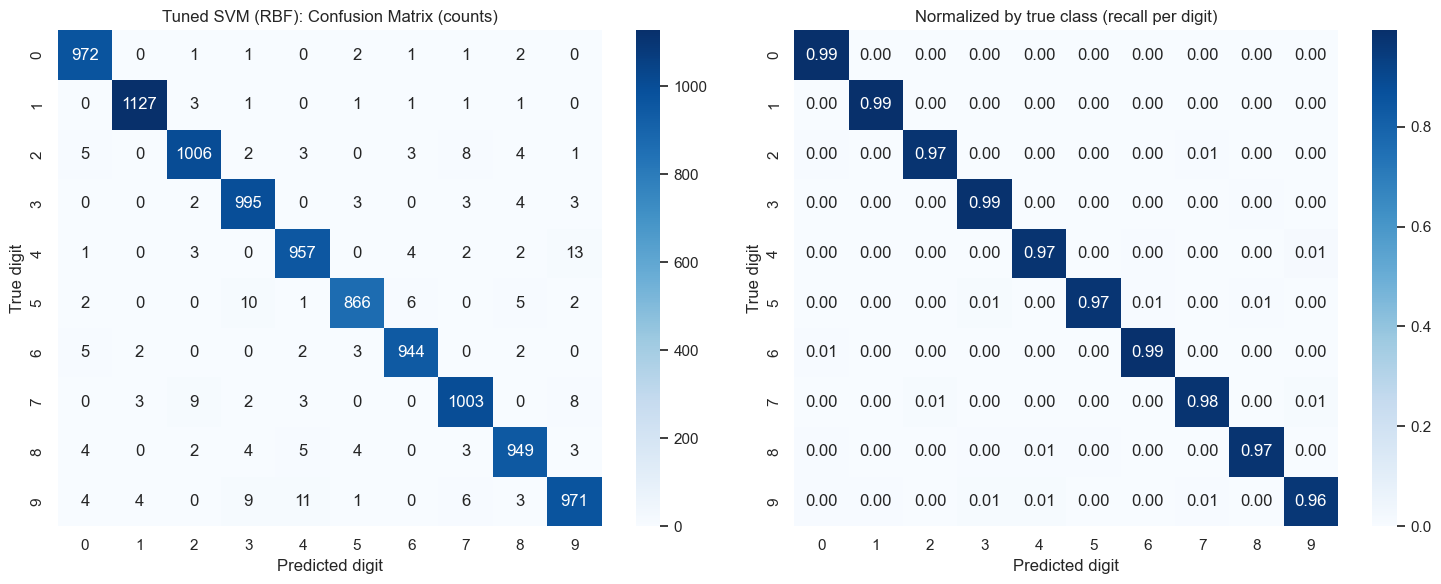

In [187]:
cm_final = confusion_matrix(y_test_final, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title(f"{final_model_name}: Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted digit")
axes[0].set_ylabel("True digit")

cm_norm = cm_final / cm_final.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=axes[1])
axes[1].set_title("Normalized by true class (recall per digit)")
axes[1].set_xlabel("Predicted digit")
axes[1].set_ylabel("True digit")

plt.tight_layout()
plt.show()

In [188]:
n = len(y_test_final)
se = np.sqrt(final_acc * (1 - final_acc) / n)
print(f"Accuracy: {final_acc:.4f} ± {1.96 * se:.4f} (approx. 95% confidence interval)")

Accuracy: 0.9790 ± 0.0028 (approx. 95% confidence interval)


In [189]:
final_summary = pd.DataFrame([{
    "Model": final_model_name,
    "Accuracy": final_acc,
    "Precision (macro)": final_prec,
    "Recall (macro)": final_rec,
    "F1 (macro)": final_f1,
    "Training images": len(X_final_train),
    "Test images": len(X_test_final),
}]).round(4)

final_summary

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),Training images,Test images
0,Tuned SVM (RBF),0.979,0.9789,0.9788,0.9788,20000,10000


In [190]:
import joblib
from pathlib import Path

# Create the models folder if it doesn't exist
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "mnist_model.pkl"
joblib.dump(final_model, model_path)

print("Saved to:", model_path.resolve())
print(f"File size: {model_path.stat().st_size / 1e6:.1f} MB")

Saved to: C:\Users\tanma\models\mnist_model.pkl
File size: 43.0 MB


In [191]:
import joblib
import numpy as np

loaded_model = joblib.load("models/mnist_model.pkl")
print(type(loaded_model))
print(loaded_model)

<class 'sklearn.svm._classes.SVC'>
SVC(C=5, gamma=0.02)


In [192]:
from tensorflow.keras.datasets import mnist

(_, _), (X_test, y_test) = mnist.load_data()

# Same preprocessing as Stage 4: flatten, then normalize
X_test_final = X_test.reshape(len(X_test), -1).astype("float32") / 255.0

# Predict a handful of images
preds = loaded_model.predict(X_test_final[:10])
print("Predictions:", preds)
print("True labels:", y_test[:10])

Predictions: [7 2 1 0 4 1 4 9 6 9]
True labels: [7 2 1 0 4 1 4 9 5 9]


In [193]:
full_pred_loaded = loaded_model.predict(X_test_final)
accuracy = np.mean(full_pred_loaded == y_test)
print(f"Loaded model accuracy on test set: {accuracy:.4f}")

Loaded model accuracy on test set: 0.9790


In [194]:
one_image = X_test_final[0]              # shape (784,)  -> 1D, will fail
print(one_image.shape)

one_image_2d = one_image.reshape(1, -1)  # shape (1, 784) -> correct
print(one_image_2d.shape)

print("Prediction:", loaded_model.predict(one_image_2d)[0])

(784,)
(1, 784)
Prediction: 7


In [195]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

preprocess = FunctionTransformer(lambda X: X.reshape(len(X), -1).astype("float32") / 255.0)

In [196]:
pip install streamlit streamlit-drawable-canvas pillow scipy

  Using cached pydeck-0.9.3-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached python_multipart-0.0.32-py3-none-any.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/10.3 MB ? eta -:--:--
   -------------- ------------------------- 3.7/10.3 MB 20.6 MB/s eta 0:00:01
   ----------------------------------- ---- 9.2/10.3 MB 22.6 MB/s eta 0:00:01
   ---------------------------------------  10.2/10.3 MB 22.7 MB/s eta 0:00:01
   ---------------------------------------- 10.3/10.3 MB 16.0 MB/s  0:00:00
Using cached pydeck-0.9.3-py2.py3-none-any.whl (11.4 MB)
Using cached python_multipart-0.0.32-py3-none-any.whl (30 kB)

   ---------------------------------------- 0/9 [websockets]
   ---- ----------------------------------- 1/9 [python-multipart]
  Attempting uninstall: protobuf
   ---- ----------------------------------- 1/9 [python-multipart]
    Found existing installation: protobuf 7.36.2
   ---- ----------------------------------- 1/9 [python-multipart]
    Uninstalli

  You can safely remove it manually.
